In [1]:
import os
import pandas as pd

import matplotlib.pyplot as plt
from numba.np.math.numbers import NAN

from data.visualize import plot_stations_on_dem, markers_from_stations_table



import peakweather

print("PeakWeather version ",peakweather.__version__)

from peakweather import PeakWeatherDataset

#Load Local Dataset
# Exclude: rain gauge stations (142) & sunshine variable
ds = PeakWeatherDataset(root="/Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset",
                        parameters = ["temperature",
                                      "pressure",
                                      "humidity",
                                      "wind_speed",
                                      "wind_gust",
                                      "wind_direction",
                                      "precipitation",
                                      ],
                        extended_topo_vars="DEM",
                        imputation_method=None,
                        compute_uv = True,
                        station_type="meteo_station")

PeakWeather version  0.2.1


### Spatial Embedding

In [2]:
print("Check number of stations:", len(ds.stations_table))

Check number of stations: 156


In [3]:
ds.stations_table.columns

Index(['station_name', 'latitude', 'longitude', 'station_height',
       'swiss_easting', 'swiss_northing', 'ASPECT_2000M_SIGRATIO1',
       'WE_DERIVATIVE_2000M_SIGRATIO1', 'TPI_2000M',
       'SN_DERIVATIVE_10000M_SIGRATIO1', 'dem',
       'SN_DERIVATIVE_2000M_SIGRATIO1', 'SLOPE_10000M_SIGRATIO1',
       'ASPECT_10000M_SIGRATIO1', 'SLOPE_2000M_SIGRATIO1', 'STD_2000M',
       'STD_10000M', 'TPI_10000M', 'WE_DERIVATIVE_10000M_SIGRATIO1',
       'station_type'],
      dtype='str')

In [5]:
coordinates = ds.stations_table[['swiss_easting', 'swiss_northing']] # spatial embedding (lat, lon) → [sin(Bx), cos(Bx)]

#Call one station⁄
ds.stations_table.drop(columns=["latitude", "longitude", "station_name", "station_type"])

,station_height,swiss_easting,swiss_northing,ASPECT_2000M_SIGRATIO1,WE_DERIVATIVE_2000M_SIGRATIO1,TPI_2000M,SN_DERIVATIVE_10000M_SIGRATIO1,dem,SN_DERIVATIVE_2000M_SIGRATIO1,SLOPE_10000M_SIGRATIO1,ASPECT_10000M_SIGRATIO1,SLOPE_2000M_SIGRATIO1,STD_2000M,STD_10000M,TPI_10000M,WE_DERIVATIVE_10000M_SIGRATIO1
nat_abbr,,,,,,,,,,,,,,,,
ABO,1321.38,2.609372e+06,1.148939e+06,124.863129,-0.167379,-53.303345,-0.026807,1317.771851,0.116605,1.702339,25.582031,11.529667,120.940262,374.830623,-443.723877,-0.012833
AEG,724.43,2.688729e+06,1.220956e+06,190.899567,0.010865,-20.030273,-0.013760,724.173462,0.056423,1.099379,315.811829,3.288559,27.269887,141.396220,-165.792114,0.013376
AIG,381.02,2.560403e+06,1.130714e+06,301.137115,0.002014,-0.256348,0.006587,381.100006,-0.001216,0.760270,119.760574,0.134786,0.000000,287.689425,-195.166718,-0.011520
ALT,437.86,2.690181e+06,1.193563e+06,240.803589,0.020179,-2.120819,-0.009294,438.587494,0.011276,0.995863,57.677086,1.324231,0.000000,493.449619,-518.464722,-0.014689
AND,987.10,2.752692e+06,1.164037e+06,285.070679,0.079193,-57.052063,-0.033264,984.354675,-0.021324,2.702750,314.800964,4.688558,71.570846,459.982181,-745.938782,0.033496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
VLS,1242.00,2.734017e+06,1.165551e+06,259.876007,0.230579,-221.533813,-0.030685,1248.217163,0.041172,2.499389,314.665771,13.182495,191.950111,420.127457,-795.717529,0.031045
WAE,485.37,2.693848e+06,1.230744e+06,30.840942,-0.056398,1.528931,-0.030955,487.379700,-0.094456,2.063067,30.759644,6.277975,57.277290,109.597974,-32.960632,-0.018423
WFJ,2691.24,2.780616e+06,1.189634e+06,102.749420,-0.120945,118.755859,-0.005864,2675.146729,0.027366,2.487068,82.240639,7.068717,84.781556,291.512251,602.742188,-0.043037


### Temporal Embedding

In [6]:
station = 'ABO'
ds.get_observations(station).head()

nat_abbr                         ABO                                        \
name                        humidity precipitation    pressure temperature   
datetime                                                                     
2017-01-01 00:00:00+00:00  30.500000           0.0  874.900024         1.1   
2017-01-01 00:10:00+00:00  30.700001           0.0  874.900024         1.2   
2017-01-01 00:20:00+00:00  34.599998           0.0  874.799988         1.2   
2017-01-01 00:30:00+00:00  27.900000           0.0  874.700012         2.0   
2017-01-01 00:40:00+00:00  32.000000           0.0  874.599976         0.5   

nat_abbr                                                                 \
name                      wind_direction wind_gust wind_speed    wind_u   
datetime                                                                  
2017-01-01 00:00:00+00:00          356.0       1.3        0.8  0.055805   
2017-01-01 00:10:00+00:00          277.0       1.8        1.0  0.992546   
2017-01-01 00:20:00+00:00          258.0       1.1        0.6  0.586889   
2017-01-01 00:30:00+00:00          306.0       1.5        0.9  0.728115   
2017-01-01 00:40:00+00:00          304.0       1.4        0.7  0.580326   

nat_abbr                             
name                         wind_v  
datetime                             
2017-01-01 00:00:00+00:00 -0.798051  
2017-01-01 00:10:00+00:00 -0.121869  
2017-01-01 00:20:00+00:00  0.124747  
2017-01-01 00:30:00+00:00 -0.529007  
2017-01-01 00:40:00+00:00 -0.391435

In [7]:
print("Start recording", ds.get_observations(station).index[0].date())
print("End recording", ds.get_observations(station).index[-1].date())

Start recording 2017-01-01
End recording 2025-10-13


In [8]:
ds.get_observations(station).index[-1] - ds.get_observations(station).index[0]

Timedelta('3207 days 23:50:00')

In [9]:
3207/365

8.786301369863013

In [10]:
ds.get_observations(station).index

DatetimeIndex(['2017-01-01 00:00:00+00:00', '2017-01-01 00:10:00+00:00',
               '2017-01-01 00:20:00+00:00', '2017-01-01 00:30:00+00:00',
               '2017-01-01 00:40:00+00:00', '2017-01-01 00:50:00+00:00',
               '2017-01-01 01:00:00+00:00', '2017-01-01 01:10:00+00:00',
               '2017-01-01 01:20:00+00:00', '2017-01-01 01:30:00+00:00',
               ...
               '2025-10-13 22:20:00+00:00', '2025-10-13 22:30:00+00:00',
               '2025-10-13 22:40:00+00:00', '2025-10-13 22:50:00+00:00',
               '2025-10-13 23:00:00+00:00', '2025-10-13 23:10:00+00:00',
               '2025-10-13 23:20:00+00:00', '2025-10-13 23:30:00+00:00',
               '2025-10-13 23:40:00+00:00', '2025-10-13 23:50:00+00:00'],
              dtype='datetime64[ns, UTC]', name='datetime', length=461952, freq='10min')

### Variables

In [11]:
ds.get_observations(station).iloc[0]

nat_abbr  name          
ABO       humidity           30.500000
          precipitation       0.000000
          pressure          874.900024
          temperature         1.100000
          wind_direction    356.000000
          wind_gust           1.300000
          wind_speed          0.800000
          wind_u              0.055805
          wind_v             -0.798051
Name: 2017-01-01 00:00:00+00:00, dtype: float32

In [12]:
ds.available_parameters

{'temperature': 'tre200s0',
 'humidity': 'ure200s0',
 'precipitation': 'rre150z0',
 'sunshine': 'sre000z0',
 'pressure': 'prestas0',
 'wind_speed': 'fkl010z0',
 'wind_gust': 'fkl010z1',
 'wind_direction': 'dkl010z0'}

#### Explore Variables Data

In [13]:
ds_day = PeakWeatherDataset(root="/Users/aureliedejong/Documents/ETH/_DAS Project/PeakWeatherDataset",
                        parameters = ["temperature",
                                      "pressure",
                                      "humidity",
                                      "wind_speed",
                                      "wind_gust",
                                      "wind_direction",
                                      "precipitation",
                                      ],
                        freq = "d",
                        station_type="meteo_station")

In [14]:
df, mask = ds_day.get_observations(
    #first_date="2024-08-02 16:32",
    #last_date="2024-08-06 23:26",
    return_mask=True,
)

long_df = mask.stack(0).rename_axis(["datetime","nat_abbr"]).reset_index()
df_time = long_df.groupby(["datetime"]).sum().drop(columns=["nat_abbr"]).reset_index()

variables = list(ds_day.parameters)

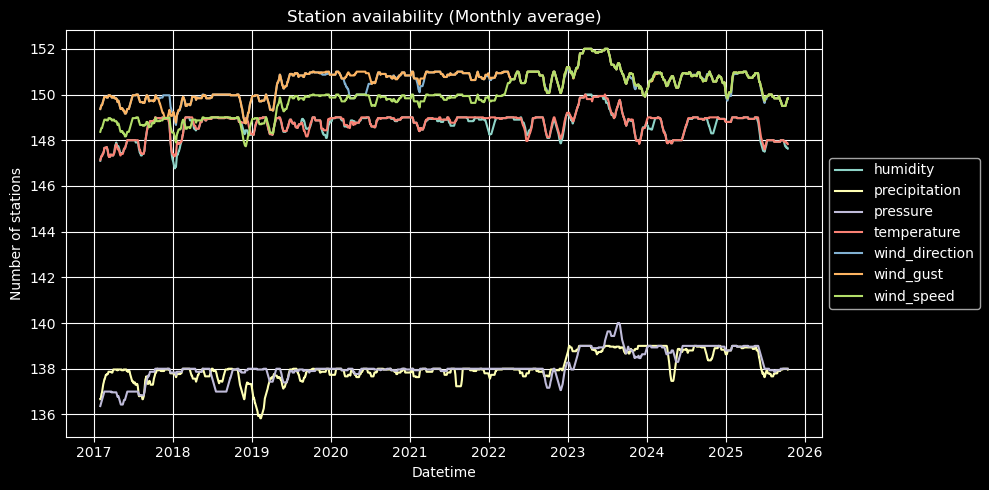

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

for v in variables:
    ax.plot(
        df_time["datetime"],
        df_time[v].rolling(30).mean(),
        label=v
    )

ax.set_title("Station availability (Monthly average)")
ax.set_ylabel("Number of stations")
ax.set_xlabel("Datetime")

# legend on the right side
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

ax.grid(True)

plt.tight_layout()
plt.show()